# Proof Step Graph Analysis

Load traced proof step graphs from JSONL and compute statistics / distributions.

In [2]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / "PyPantograph"))
from proof_step_graph.graph import ProofStepGraph, NODE_GOAL, NODE_TACTIC

In [3]:
# ── Load graphs ──────────────────────────────────────────────────────────────
JSONL_PATH = Path("../data/mathlib_all_graphs.jsonl")

graphs = []
with JSONL_PATH.open() as f:
    for line in f:
        line = line.strip()
        if line:
            graphs.append(ProofStepGraph.from_dict(json.loads(line)))

print(f"Loaded {len(graphs)} proof step graphs")

Loaded 12016 proof step graphs


## Summary statistics

In [4]:
df = pd.DataFrame([pg.stats() for pg in graphs])

print(f"{'='*55}")
print(f"  Proof Step Graph Summary  ({len(df)} theorems)")
print(f"{'='*55}")
for col in df.select_dtypes(include="number").columns:
    print(f"  {col:<25} mean={df[col].mean():.2f}  max={df[col].max()}")
print(f"  is_dag ratio: {df['is_dag'].mean():.2%}")

df.describe()

  Proof Step Graph Summary  (12016 theorems)
  n_goals                   mean=3.58  max=132
  n_tactics                 mean=3.68  max=133
  n_initial_goals           mean=1.00  max=1
  n_terminal_goals          mean=0.02  max=3
  n_edges                   mean=5.77  max=245
  max_branching             mean=0.75  max=18
  avg_branching             mean=0.34  max=1.5
  is_dag ratio: 99.98%


,n_goals,n_tactics,n_initial_goals,n_terminal_goals,n_edges,max_branching,avg_branching
count,12016.000000,12016.000000,12016.0,12016.000000,12016.000000,12016.000000,12016.000000
mean,3.577314,3.681258,1.0,0.018392,5.766894,0.749417,0.338027
std,5.138629,5.448455,0.0,0.159310,9.634874,0.858751,0.324051
min,1.000000,1.000000,1.0,0.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,1.0,0.000000,1.000000,0.000000,0.000000
50%,2.000000,2.000000,1.0,0.000000,3.000000,1.000000,0.500000
75%,4.000000,4.000000,1.0,0.000000,6.000000,1.000000,0.666667
max,132.000000,133.000000,1.0,3.000000,245.000000,18.000000,1.500000


## Distributions

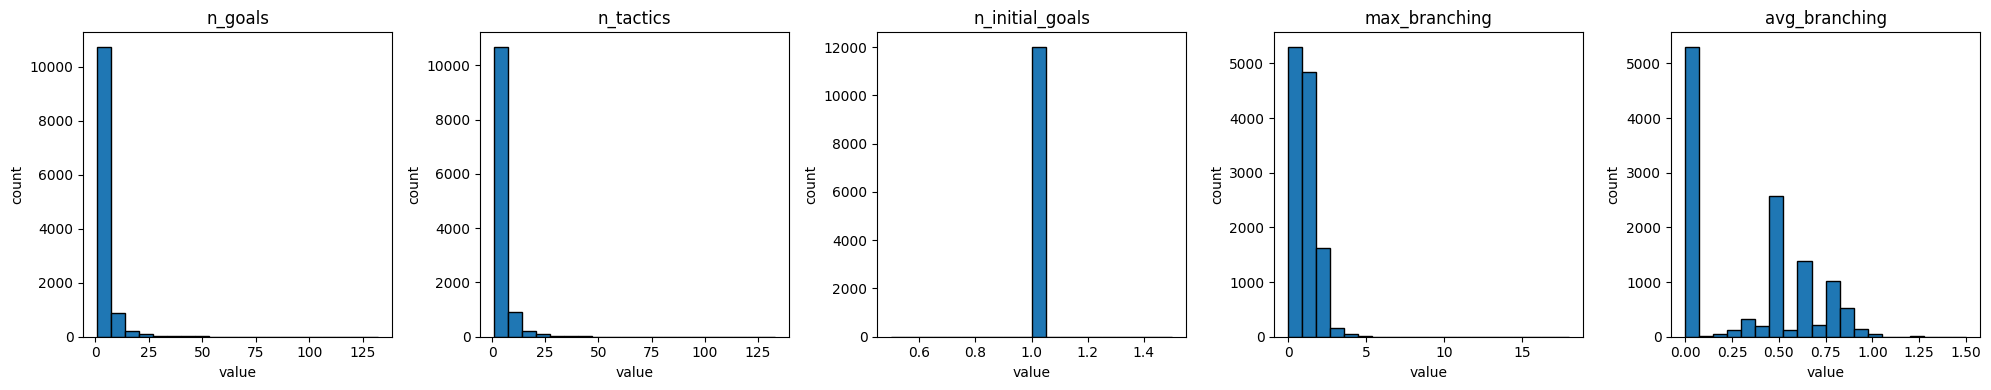

In [5]:
cols = ["n_goals", "n_tactics", "n_initial_goals", "max_branching", "avg_branching"]

fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4))
for ax, col in zip(axes, cols):
    ax.hist(df[col].dropna(), bins=20, edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
fig.tight_layout()
plt.show()

## Branching vs depth

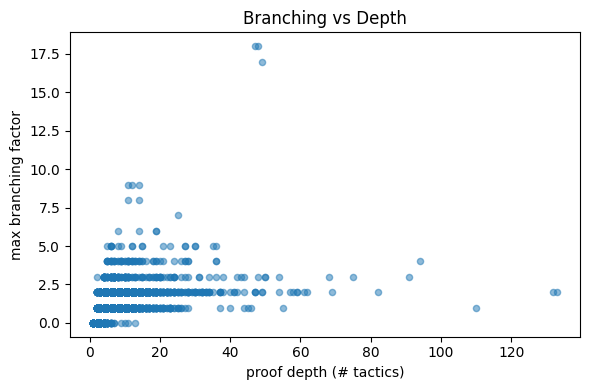

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["n_tactics"], df["max_branching"], alpha=0.5, s=20)
ax.set_xlabel("proof depth (# tactics)")
ax.set_ylabel("max branching factor")
ax.set_title("Branching vs Depth")
fig.tight_layout()
plt.show()

## Tactic frequency

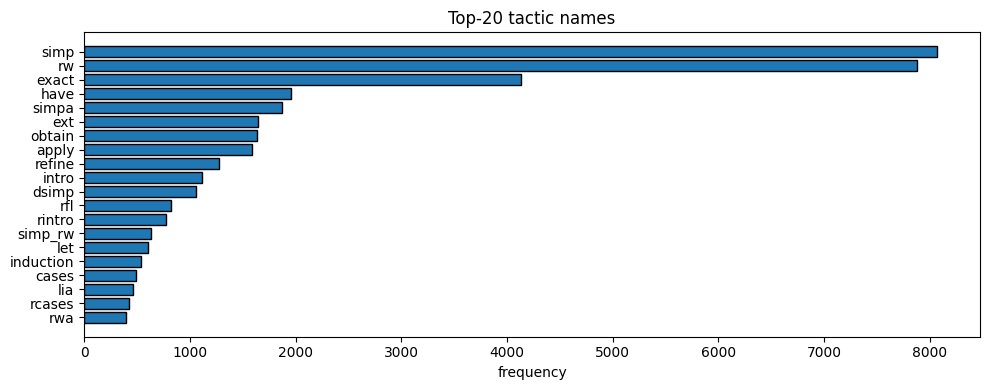

In [7]:
TOP_N = 20

counter: Counter = Counter()
for pg in graphs:
    for _, d in pg.tactic_nodes():
        tac = d["tactic"].split()[0].rstrip(";").rstrip("<;>")
        counter[tac] += 1

top = counter.most_common(TOP_N)
names, counts = zip(*top) if top else ([], [])

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(names, counts, edgecolor="black")
ax.set_xlabel("frequency")
ax.set_title(f"Top-{TOP_N} tactic names")
ax.invert_yaxis()
fig.tight_layout()
plt.show()